# 1. 데이터 로드 및 병합
- 7개의 원본 CSV를 로드하고 하나의 Master DataFrame으로 병합합니다.

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

def load_and_merge():
    files = {
        '기본정보': '기본정보.csv', '면적정보': '면적정보.csv', '시설정보': '시설정보.csv',
        '운영정보': '운영정보.csv', '위치정보': '위치정보.csv', '장기수선': '장기수선.csv', '관리비': '관리비.csv'
    }
    dfs = {}
    for name, filename in files.items():
        path = os.path.join(DATA_DIR, filename)
        try:
            dfs[name] = pd.read_csv(path, encoding='utf-8')
        except UnicodeDecodeError:
            dfs[name] = pd.read_csv(path, encoding='cp949')

    if '면적정보' in dfs:
        dfs['면적정보'] = dfs['면적정보'].drop_duplicates(subset=['단지코드']).drop(columns=['주거전용면적(세부)', '세대수'], errors='ignore')

    static_df = dfs['기본정보']
    for table_name in ['면적정보', '시설정보', '운영정보', '위치정보']:
        df_to_merge = dfs[table_name]
        cols_to_use = [col for col in df_to_merge.columns if col not in static_df.columns or col == '단지코드']
        static_df = pd.merge(static_df, df_to_merge[cols_to_use], on='단지코드', how='left')
    
    ts_df = dfs['관리비']
    repair_df = dfs['장기수선']
    join_keys = ['단지코드', '발생년월(YYYYMM)']
    cols_to_use = [col for col in repair_df.columns if col not in ts_df.columns or col in join_keys]
    ts_df = pd.merge(ts_df, repair_df[cols_to_use], on=join_keys, how='left')
    
    raw_master_df = pd.merge(ts_df, static_df, on='단지코드', how='left')
    return raw_master_df

raw_master_df = load_and_merge()
print(f"병합 완료된 원본 데이터 크기: {raw_master_df.shape}")
raw_master_df.head()

병합 완료된 원본 데이터 크기: (147240, 87)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


# 2. 데이터 전처리
- 2-1. 결측치 처리
- 2-2. 칼럼 삭제
- 2-3. 파생변수 생성
- 2-4. 다중공선성 확인 (VIF)

## 2-1. 결측치 처리
- `경비관리-인원`(0.49%, 12개 단지) 결측치를 **세대수 사분위 구간 × 관리방식 그룹 중앙값**으로 대치합니다.
- 그 외 관리비/시설 항목의 0값들(난방비, 임대세대수 등)은 결측이 아니라 정당한 값(구조적 0·이벤트성 0)으로 판단되어 별도 처리하지 않습니다.
- 근거 및 검증 과정: `문서/작업과정/결측치_처리_점검_20260826.md`

In [2]:
def handle_missing_values(df):
    df = df.copy()
    missing_codes = df.loc[df['경비관리-인원'].isna(), '단지코드'].unique()

    complexes = df.drop_duplicates('단지코드').copy()
    q1, q2, q3 = complexes['세대수'].quantile([.25, .5, .75])

    def bucket_size(x):
        if x <= q1:
            return '소형'
        if x <= q2:
            return '중소형'
        if x <= q3:
            return '중대형'
        return '대형'

    complexes['세대수구간'] = complexes['세대수'].apply(bucket_size)
    df = df.merge(complexes[['단지코드', '세대수구간']], on='단지코드', how='left')

    group_median = (
        df.dropna(subset=['경비관리-인원'])
        .groupby(['세대수구간', '관리방식'])['경비관리-인원']
        .median()
    )

    def impute_guard_staff(row):
        if pd.notna(row['경비관리-인원']):
            return row['경비관리-인원']
        key = (row['세대수구간'], row['관리방식'])
        if key in group_median.index:
            return group_median.loc[key]
        return group_median.loc[row['세대수구간']].median()  # fallback: 관리방식 무시하고 세대수구간 전체 중앙값

    df['경비관리-인원'] = df.apply(impute_guard_staff, axis=1)
    df = df.drop(columns=['세대수구간'])

    print(f"결측치 대치 완료: {len(missing_codes)}개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치")
    print(f"대치 후 남은 결측 수: {df['경비관리-인원'].isna().sum()}")
    return df

raw_master_df = handle_missing_values(raw_master_df)
raw_master_df.head()

결측치 대치 완료: 12개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치
대치 후 남은 결측 수: 0


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 2-2. 칼럼 삭제
- 병합된 데이터프레임에서 불필요한 칼럼을 삭제합니다.
- `장충금 적립률`은 2026-08-26 팀 결정으로 삭제 목록에 추가했습니다 (0값 비율의 원인을 설명할 수 없어 삭제 — 근거는 위 결측치 처리 점검 문서 참고).

In [3]:
def preprocess_data(df):
    cols_to_drop = [
        '차량유지비', '지능형네트워크유지비', '재해예방비', '가스사용료(공용)', '가스사용료(전용)', '기타', '제세공과금', '교육훈련비', '시설유지비', '안전점검비', '위탁관리수수료', '급탕비(공용)', '수도료(공용)', 'TV수신료', '정화조오물수수료', '선관위운영비',
        '시공사', '주택관리업자',
        '건물구조', '전기-수전용량', '전기-세대전기계약방식', '승강기관리-관리방식', 'CCTV대수', '부대복리시설', '홈네트워크',
        '경비관리-계약업체', '청소관리-계약업체', '음식물 처리방법', '소독관리-계약업체', '일반관리-관리방식', '경비관리-관리방식', '청소관리-관리방식', '소독관리-관리방식',
        '입주자기여수익', '공동기여수익',
        '장충금 적립률',  # 2026-08-26 팀 결정: 0비율 원인 설명 불가로 삭제
    ]
    existing_cols = [col for col in cols_to_drop if col in df.columns]
    df_cleaned = df.drop(columns=existing_cols)
    
    print(f"삭제된 칼럼 수: {len(existing_cols)}개")
    print(f"전처리 완료 후 최종 남은 데이터 크기: {df_cleaned.shape}")
    return df_cleaned

final_df = preprocess_data(raw_master_df)
final_df.head()

삭제된 칼럼 수: 34개
전처리 완료 후 최종 남은 데이터 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,피복비,그밖의부대비용,청소비,경비비,소독비,...,주거전용면적(단지합계),승강기대수,총주차대수,최고층수,지하층수,일반관리-인원,경비관리-인원,청소관리-인원,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,0,341860,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,0,326160,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,0,711840,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,0,315660,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,0,398410,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151


## 2-3. 파생변수 생성
- 비용 항목 24개 + 시설·인원 5개(승강기대수, 총주차대수, 일반/경비/청소관리-인원)를 `관리비부과면적` 기준으로 정규화(`_perm2`)하여 `per_df`를 만듭니다.
- `동수`, `분양세대수`/`임대세대수`는 이번엔 파생변수를 만들지 않고 원값 그대로 둡니다.
- 상세 근거: [의사결정 로그](https://app.notion.com/p/3c9831afe087812ba44bfe9b8fad522e)

In [4]:
# 관리비부과면적당 단가로 환산할 금액(비용) 컬럼 목록
AMOUNT_COLS = [
    # 관리비.csv 유래
    '공용관리비계', '인건비', '제사무비', '피복비', '그밖의부대비용', '청소비', '경비비', '소독비',
    '승강기유지비', '수선비', '개별사용료계', '난방비(공용)', '난방비(전용)', '급탕비(전용)',
    '전기료(공용)', '전기료(전용)', '수도료(전용)', '생활폐기물수수료', '입대의운영비', '건물보험료',
    # 장기수선.csv 유래
    '장충금 월부과액', '장충금 월사용액', '장충금 총적립금액', '잡수입 월수입금액',
    # 시설·인원 수 (2026-08-27 팀 결정: 세대수 대신 관리비부과면적 기준으로 정규화. 동수는 제외)
    '승강기대수', '총주차대수', '일반관리-인원', '경비관리-인원', '청소관리-인원',
]

def calc_per_area(df, amount_cols=AMOUNT_COLS, area_col='관리비부과면적'):
    cols = [c for c in amount_cols if c in df.columns]
    df_perm2 = df.copy()
    df_perm2[cols] = df[cols].div(df[area_col], axis=0)
    df_perm2 = df_perm2.rename(columns={c: f'{c}_perm2' for c in cols})
    return df_perm2

per_df = calc_per_area(final_df)
print(f"per_df 크기: {per_df.shape}")
per_df.head()

per_df 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계_perm2,인건비_perm2,제사무비_perm2,피복비_perm2,그밖의부대비용_perm2,청소비_perm2,경비비_perm2,소독비_perm2,...,주거전용면적(단지합계),승강기대수_perm2,총주차대수_perm2,최고층수,지하층수,일반관리-인원_perm2,경비관리-인원_perm2,청소관리-인원_perm2,위도,경도
0,A11007001,202101,1389.459752,561.390304,6.472770,0.0,8.904552,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
1,A11007001,202102,1385.437387,561.388793,6.462351,0.0,8.495608,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
2,A11007001,202103,1386.470869,561.388845,5.951823,0.0,18.541556,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
3,A11007001,202104,1354.353739,533.591723,6.352952,0.0,8.222111,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
4,A11007001,202105,1364.475328,533.831880,6.019546,0.0,10.377531,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151


## 2-4. 다중공선성 확인 (VIF)

**VIF (Variance Inflation Factor)**
- 각 독립변수 하나를 종속변수처럼 놓고 나머지 모든 독립변수로 회귀시켰을 때의 결정계수($R_i^2$)를 이용합니다.

$$VIF_i = \frac{1}{1 - R_i^2}$$

- $R_i^2$가 1에 가까울수록(다른 변수들로 거의 완벽히 설명됨) VIF는 무한대로 발산합니다.
- 단순 상관계수와 달리 **다른 모든 변수를 동시에 고려한 상태에서** 해당 변수가 얼마나 "중복 정보"인지를 봅니다.
- 해석 기준(일반적 관행): VIF < 5 문제 없음 / 5 ≤ VIF < 10 주의 / VIF ≥ 10 심각한 다중공선성

`per_df`의 면적당단가(`_perm2`) 파생변수와 규모/입지/연식 변수들 간 다중공선성을 VIF로 확인합니다.

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calc_vif(df, cols):
    X = add_constant(df[cols].dropna())
    vif_df = pd.DataFrame({
        'variable': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df

perm2_cols = [c for c in per_df.columns if c.endswith('_perm2')]

# 건물 사용연수: 데이터 발생시점(발생년월)을 기준으로 사용승인일로부터 경과한 연수
approval_date = pd.to_datetime(per_df['사용승인일'].astype(str), format='%Y%m%d')
record_date = pd.to_datetime(per_df['발생년월(YYYYMM)'].astype(str) + '01', format='%Y%m%d')
per_df['사용연수'] = (record_date - approval_date).dt.days / 365.25

# 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로 발생한 음수는 0으로 대체
negative_age_count = (per_df['사용연수'] < 0).sum()
per_df.loc[per_df['사용연수'] < 0, '사용연수'] = 0
print(f"사용연수 음수 {negative_age_count}행을 0으로 대체")

# 합계(계) 컬럼은 하위 세부 항목들의 선형결합이라 구조적으로 VIF를 부풀리므로 제외
SUM_COLS_TO_EXCLUDE = ['개별사용료계_perm2', '공용관리비계_perm2']
EXTRA_COLS = ['세대수', '최고층수', '지하층수', '위도', '경도', '사용연수']
vif_cols = [c for c in perm2_cols if c not in SUM_COLS_TO_EXCLUDE] + EXTRA_COLS

vif_df = calc_vif(per_df, vif_cols)
print(f"VIF 계산 대상: {len(vif_cols)}개 변수 (세부항목 27개 + 규모/입지/연식 변수 {len(EXTRA_COLS)}개), 샘플 수: {per_df[vif_cols].dropna().shape[0]}")
vif_df

사용연수 음수 108행을 0으로 대체


VIF 계산 대상: 33개 변수 (세부항목 27개 + 규모/입지/연식 변수 6개), 샘플 수: 147240


,variable,VIF
0,경비관리-인원_perm2,4.219897
1,경비비_perm2,3.967347
2,청소관리-인원_perm2,3.746708
3,청소비_perm2,3.528765
4,일반관리-인원_perm2,3.485247
5,인건비_perm2,3.004267
6,사용연수,2.829172
7,총주차대수_perm2,2.318049
8,급탕비(전용)_perm2,2.099546
9,최고층수,1.850820


**결과 해석**
- 초기 29개 `_perm2` 변수 중 `개별사용료계_perm2`(43.2), `공용관리비계_perm2`(25.7) 등이 VIF 10을 초과 — 하위 세부 항목들의 **합계(선형결합)**라서 구조적으로 발생하는 문제입니다.
- 두 합계 컬럼을 제외하고 세부 항목 27개 + 규모/입지/연식 변수 6개(`세대수`, `최고층수`, `지하층수`, `위도`, `경도`, `사용연수`) 총 33개로 재계산하면 **최댓값 4.2**로 전부 5 미만입니다.
- `사용연수` 음수 108행(0.07%)은 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로, 0으로 대체했습니다.
- **결론**: 모델링 시 합계 컬럼 2개는 제외하고, 나머지 33개 변수를 사용하는 것을 권장합니다.

In [6]:
# 3. PCA 검토: VIF를 통과한 33개 변수를 표준화
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_data = per_df[vif_cols].dropna()
X_scaled = StandardScaler().fit_transform(pca_data)
print(f'PCA 입력: {pca_data.shape[0]:,}행 × {pca_data.shape[1]}변수')

PCA 입력: 147,240행 × 33변수


In [7]:
# 90%는 최적값이 아니므로 여러 설명분산 기준을 함께 비교
pca = PCA().fit(X_scaled)
cumulative_variance = pca.explained_variance_ratio_.cumsum()
thresholds = [0.80, 0.85, 0.90, 0.95]
pca_thresholds = pd.DataFrame({
    '누적설명분산기준': thresholds,
    '필요주성분수': [int(np.searchsorted(cumulative_variance, t) + 1) for t in thresholds],
})
pca_thresholds.style.format({'누적설명분산기준': '{:.0%}'})

,누적설명분산기준,필요주성분수
0,80%,18
1,85%,21
2,90%,24
3,95%,27


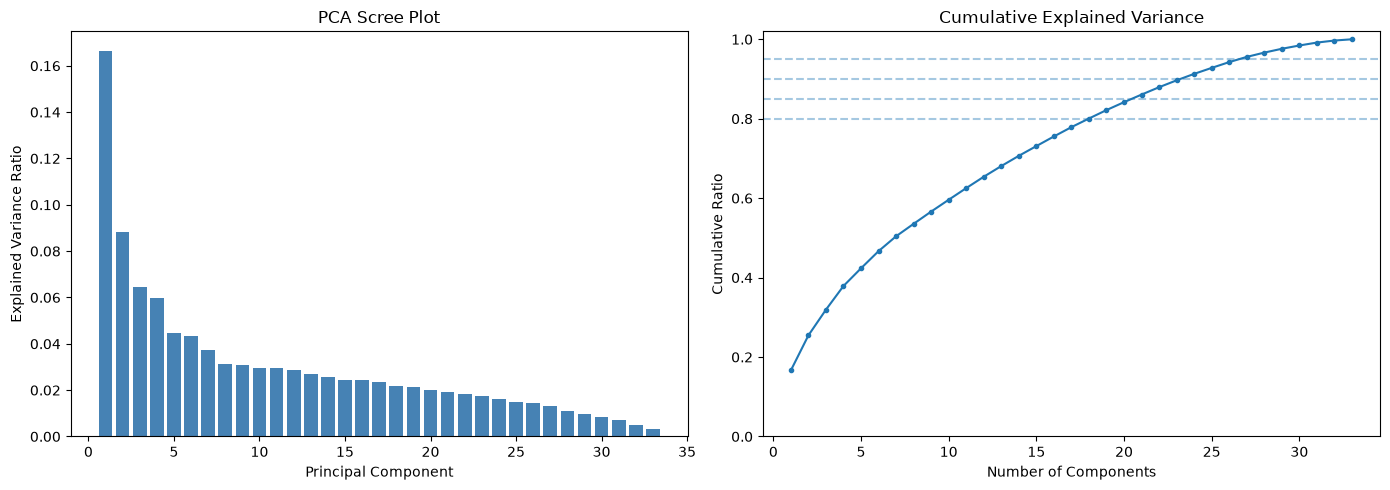

In [8]:
# 차원 축소 효과 확인
components = np.arange(1, len(vif_cols) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(components, pca.explained_variance_ratio_, color='steelblue')
axes[0].set(title='PCA Scree Plot', xlabel='Principal Component', ylabel='Explained Variance Ratio')
axes[1].plot(components, cumulative_variance, marker='o', markersize=3)
for threshold in thresholds:
    axes[1].axhline(threshold, linestyle='--', alpha=0.4)
axes[1].set(title='Cumulative Explained Variance', xlabel='Number of Components', ylabel='Cumulative Ratio', ylim=(0, 1.02))
plt.tight_layout()
plt.show()

## 3. PCA 검토 결과 해석

- 누적 설명분산 80%에는 18개, 85%에는 21개, 90%에는 24개, 95%에는 27개 주성분이 필요합니다. 90%는 수학적으로 정해진 최적값이 아니라 비교용 기준입니다.
- 90% 기준에서 33개가 24개로 줄어 압축 효과가 크지 않습니다. 현재 33개 변수는 VIF 검토를 통과했고 모델링에 과도한 수가 아니므로 PCA를 필수 전처리로 적용할 필요는 낮습니다.
- 각 주성분은 특정 원본 컬럼을 삭제한 결과가 아니라 원본 33개 변수 전체의 가중합입니다. PCA를 적용하면 관리비 항목별 영향 해석이 어려워집니다.
- K-means에서는 PCA가 거리 계산의 중복·노이즈를 줄일 수 있지만 필수는 아닙니다. **표준화한 원본 변수 K-means와 PCA K-means를 동일한 조건에서 비교**하고 군집 품질과 안정성이 실제로 개선될 때만 PCA를 채택합니다.
- 단지 유형을 군집화하려면 월별 147,240행을 그대로 사용하지 않고, 먼저 2,454개 단지 단위의 평균·변동성·추세 특성으로 집계해야 합니다.

# 4. 1단계 구조 군집 변수 준비

`클러스터링_통합_작업계획서_v2_20260828`의 오늘 목표 1번: `평균전용면적` 파생변수를 `주거전용면적(단지합계) ÷ 세대수`로 단지 단위로 계산합니다.

In [9]:
# 세대수·주거전용면적(단지합계)은 단지별 고정값이므로 단지 단위(2,454행)로 축약한 뒤 계산
complex_df = per_df[['단지코드', '세대수', '주거전용면적(단지합계)']].drop_duplicates('단지코드').reset_index(drop=True)
complex_df['평균전용면적'] = complex_df['주거전용면적(단지합계)'] / complex_df['세대수']

print(f"단지 단위 데이터 크기: {complex_df.shape}")
complex_df.describe()

단지 단위 데이터 크기: (2454, 4)


,세대수,주거전용면적(단지합계),평균전용면적
count,2454.000000,2454.000000,2454.000000
mean,616.143847,47724.591844,92.438892
std,645.864585,54135.716806,251.154083
min,4.000000,2341.120000,11.826117
25%,241.000000,18112.265000,69.788706
50%,408.000000,31382.070000,79.736109
75%,736.750000,57000.502500,86.757203
max,9510.000000,734780.750000,6319.457143


In [10]:
# `평균전용면적`을 per_df(월별 147,240행)에도 추가 — 원본 소스 컬럼이 이미 row-level로 존재하므로 직접 계산
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

print(f"per_df 크기: {per_df.shape}")
per_df[['단지코드', '세대수', '주거전용면적(단지합계)', '평균전용면적']].head()

per_df 크기: (147240, 55)


,단지코드,세대수,주거전용면적(단지합계),평균전용면적
0,A11007001,150,22444.8,149.632
1,A11007001,150,22444.8,149.632
2,A11007001,150,22444.8,149.632
3,A11007001,150,22444.8,149.632
4,A11007001,150,22444.8,149.632
